# Exploratory Data Analysis

This notebook explores the dataset collected from theses.fr.  
The goal is to understand the size, structure, missing values, and main characteristics of the corpus before building retrieval models.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

## 1. Loading the dataset

We load the processed dataset generated by `src.preprocess`.

In [2]:
DATA_PATH = Path("../data/processed/theses_clean.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,id,title,title_en,abstract,year,discipline,subjects,institution,status,url,text
0,s431762,Artificial Intelligence and Economic Dynamics,Intelligence Artificielle et Dynamiques Econom...,Ce projet de thèse vise à explorer l'utilisati...,2025.0,Sciences économiques - EM2PSI,Intelligence Artificielle ; Economie ; Urbaine...,CY Cergy Paris Université,enCours,https://theses.fr/s431762,Artificial Intelligence and Economic Dynamics....
1,2023STRAB011,Artificial intelligence in science : diffusion...,Intelligence artificielle en science : diffusi...,Cette thèse étudie l'impact de l'intelligence ...,2023.0,Sciences économiques,Intelligence artificielle ; Equipes scientifiq...,Strasbourg,soutenue,https://theses.fr/2023STRAB011,Artificial intelligence in science : diffusion...
2,s372280,L'intelligence artificielle dans les interacti...,Artificial intelligence in patient/doctor inte...,L'intelligence artificielle dans les interacti...,2023.0,Sciences de l'Information et de la Communication,Interaction patient/médecin ; Intelligence art...,Université Gustave Eiffel,enCours,https://theses.fr/s372280,L'intelligence artificielle dans les interacti...
3,2024STRAB004,The role of artificial intelligence for societ...,Le rôle de l'intelligence artificielle dans le...,Cette thèse examine le rôle de l'intelligence ...,2024.0,Sciences économiques,Intelligence Artificielle ; 4ème Révolution In...,Strasbourg,soutenue,https://theses.fr/2024STRAB004,The role of artificial intelligence for societ...
4,s377938,MetagenomIA : Intelligence artificielle pour l...,MetagenomIA : Artificiel Intelligence for emer...,Introduction au problème L'émergence incessant...,2023.0,Pathologie et recherche clinique,Intelligence artificielle ; Émergence ; Métage...,Paris 12,enCours,https://theses.fr/s377938,MetagenomIA : Intelligence artificielle pour l...


### Shape and Columns

In [3]:
df.shape, df.columns.tolist()

((18242, 11),
 ['id',
  'title',
  'title_en',
  'abstract',
  'year',
  'discipline',
  'subjects',
  'institution',
  'status',
  'url',
  'text'])

### Missing values

Missing values are important because the retrieval models depend mainly on textual fields such as titles and abstracts.

In [4]:
df.isna().sum()

id                0
title             0
title_en       1395
abstract       1411
year              1
discipline        0
subjects       4027
institution       0
status            0
url               0
text              0
dtype: int64

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing_rate = (df.isna().mean() * 100).sort_values(ascending=False)

pd.DataFrame({
    "missing_count": missing,
    "missing_rate_percent": missing_rate.round(2),
})

,missing_count,missing_rate_percent
subjects,4027,22.08
abstract,1411,7.73
title_en,1395,7.65
year,1,0.01
id,0,0.00
title,0,0.00
discipline,0,0.00
institution,0,0.00
status,0,0.00
url,0,0.00


### Text length analysis

We analyze the length of titles, abstracts, and final search texts. This helps identify very short or empty documents.

In [6]:
df["title_length"] = df["title"].fillna("").str.len()
df["abstract_length"] = df["abstract"].fillna("").str.len()
df["text_length"] = df["text"].fillna("").str.len()

df[["title_length", "abstract_length", "text_length"]].describe()

,title_length,abstract_length,text_length
count,18242.000000,18242.000000,18242.000000
mean,103.797884,1877.159303,2068.826170
std,39.273866,1330.669521,1341.138369
min,7.000000,0.000000,34.000000
25%,75.000000,1166.250000,1359.000000
50%,99.000000,1697.000000,1910.000000
75%,126.000000,2472.000000,2664.000000
max,468.000000,50132.000000,50460.000000


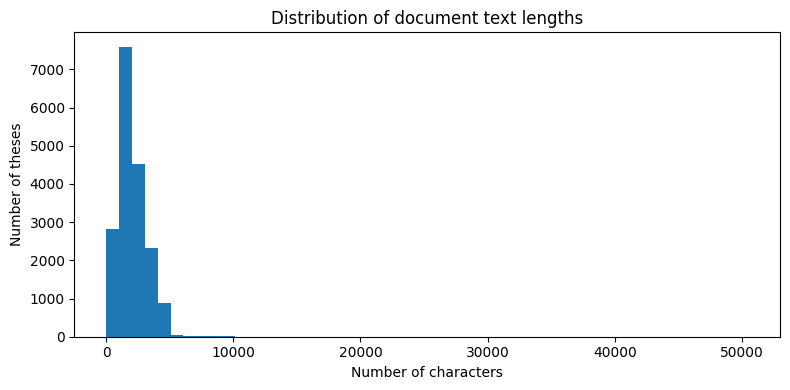

In [7]:
df["text_length"].plot(kind="hist", bins=50, figsize=(8, 4))
plt.title("Distribution of document text lengths")
plt.xlabel("Number of characters")
plt.ylabel("Number of theses")
plt.tight_layout()
plt.show()

### Disciplines

We inspect the most frequent disciplines to understand the thematic coverage of the collected corpus.

In [8]:
df["discipline"].value_counts().head(20)

discipline
Informatique                                                        3734
Mathématiques appliquées                                             467
Physique                                                             451
Sciences appliquées                                                  436
Neurosciences                                                        403
Mathématiques                                                        323
Sciences et technologies de l'information et de la communication     243
Sciences de gestion                                                  239
Sciences économiques                                                 213
Informatique et applications                                         203
Informatique, données, IA                                            197
Sciences de l'information et de la communication                     192
Sciences du langage                                                  188
Sciences de l'éducation                 

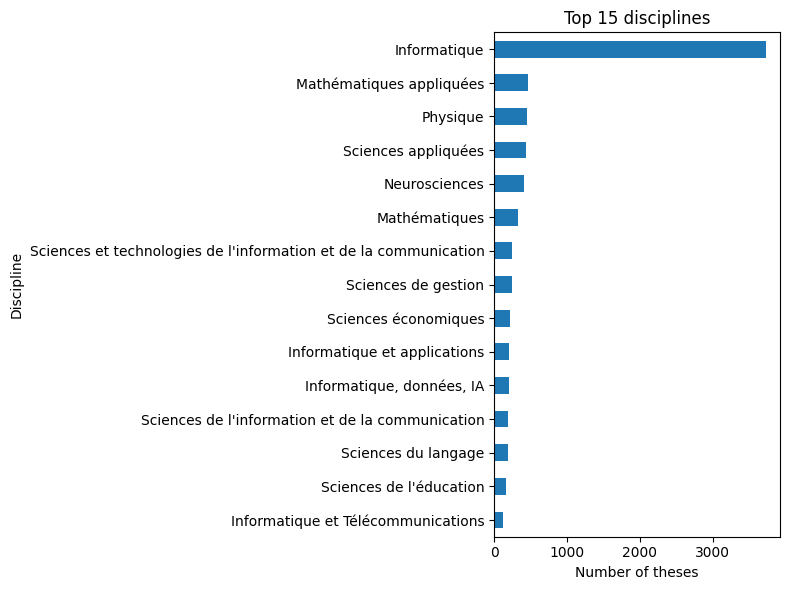

In [9]:
df["discipline"].value_counts().head(15).sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Top 15 disciplines")
plt.xlabel("Number of theses")
plt.ylabel("Discipline")
plt.tight_layout()
plt.show()

### Year distribution

If the year field is available, we inspect the temporal coverage of the corpus.

In [10]:
if "year" in df.columns and df["year"].notna().any():
    year_counts = df["year"].value_counts().sort_index()
    display(year_counts.tail(30))
else:
    print("The year field is currently empty or unavailable.")

year
1997.0     221
1998.0     210
1999.0     199
2000.0     190
2001.0     148
2002.0     142
2003.0     156
2004.0     176
2005.0     210
2006.0     222
2007.0     275
2008.0     286
2009.0     262
2010.0     305
2011.0     313
2012.0     331
2013.0     351
2014.0     386
2015.0     392
2016.0     428
2017.0     448
2018.0     513
2019.0     605
2020.0     633
2021.0     879
2022.0    1212
2023.0    1952
2024.0    2268
2025.0    2236
2026.0     255
Name: count, dtype: int64

In [12]:
df["year"].describe()
df["year"].value_counts().sort_index().tail(15)

year
2012.0     331
2013.0     351
2014.0     386
2015.0     392
2016.0     428
2017.0     448
2018.0     513
2019.0     605
2020.0     633
2021.0     879
2022.0    1212
2023.0    1952
2024.0    2268
2025.0    2236
2026.0     255
Name: count, dtype: int64

### Examples of searchable documents

We inspect a few examples of the final `text` field used by retrieval models.

In [11]:
for i, row in df.sample(3, random_state=42).iterrows():
    print("=" * 100)
    print("TITLE:", row["title"])
    print("DISCIPLINE:", row["discipline"])
    print("TEXT:", row["text"][:1000])

TITLE: AIDY : application of Artificial Intelligence to Dysmorphology
DISCIPLINE: Technologies d'application médicale, diagnostiques, thérapies et santé publique
TEXT: AIDY : application of Artificial Intelligence to Dysmorphology. AIDY : application of Artificial Intelligence to Dysmorphology. Contexte. Trente à quarante pourcents des 7000 maladies rares entraînent des anomalies crânio-faciales et certaines nécessitent l'œil expert d'un dysmorphologiste. Le diagnostic, dans cette discipline, est basé avant tout sur l'expérience du praticien. Pour cette raison, les publications scientifiques décrivant des méthodes de diagnostic automatique de ces maladies rares à partir de photographies 2D de visages se multiplient. Ces méthodes peuvent être regroupées sous le terme de Phénotypage Nouvelle Génération (PNG). Ce travail de thèse a pour objectif de décrire de décrire les performances d'un nouvel outil de PNG basé sur des photographies 2D de visages d'enfants, entraîné sur une base non pub